# Assignment: detecting a grid anomaly from regression residuals

Winter Storm Uri caused widespread generation failures across Texas in February 2021. As temperatures
fell and demand rose, ERCOT began shedding load early on 15 February to prevent a wider grid collapse.
Millions of customers lost power, and the consequences were severe. Read the background article linked below
to understand the event before starting the assignment.
[2021 Texas power crisis](https://en.wikipedia.org/wiki/2021_Texas_power_crisis).


You will fit a model of normal grid behaviour and test whether its residuals distinguish the storm week
from an ordinary week. Use the ridge regression from the [linear regression](https://aegean.ai/aiml-common/lectures/regression/linear-regression) and
[SGD](https://aegean.ai/aiml-common/lectures/regression/linear-regression/sgd) pages, fitted by
stochastic gradient descent. This assignment uses a richer design matrix than those examples.

Build a detection rule from the residuals and evaluate it against the control week. Report the result even
if the two windows do not separate cleanly.

## Points

| Component | Points |
|---|---|
| Data retrieval and the load and temperature join | 10 |
| Design matrix construction | 15 |
| Ridge fitted by SGD, with lambda selected on held-out error | 20 |
| Model correctly frozen and applied to both evaluation windows | 15 |
| Signed residual analysis | 15 |
| Detection rule, threshold choice and evaluation against the control | 15 |
| Written discussion | 10 |

In [37]:
!pip install gridstatusio python-dotenv
!pip install Optuna

In [38]:
import os
from google.colab import userdata

os.environ["GRIDSTATUS_API_KEY"] = userdata.get("GRIDSTATUS_API_KEY")

In [39]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from gridstatusio import GridStatusClient

load_dotenv()
client = GridStatusClient(os.environ["GRIDSTATUS_API_KEY"])

## Part 0: why time of day is not enough

The SGD example models load against time of day. That is not enough here: winter demand also depends
strongly on temperature.

An anomaly score is useful only if the baseline is reasonably accurate on ordinary days. Begin by measuring
that baseline error.


The design matrix includes nonlinear temperature terms, calendar indicators, and interactions between
temperature and hour of day.

### The three windows

The analysis uses three time windows.

| Window | Familiar name | What it is for |
|---|---|---|
| `train` | training set | fits the weights, the scalers and $\lambda$ |
| `control` | test set | data the model has never seen, on ordinary days |
| `event` | no equivalent | the week you are asking about |

Training error is an optimistic reference because the model was fitted on those observations. The control
window provides a better estimate of ordinary out-of-sample error. Compare the event residuals with that
control distribution.



In [40]:
ZONES = ["coast", "east", "far_west", "north", "north_central", "south_central", "southern", "west"]

def fetch_window(start, end):
    """Hourly ERCOT load joined to statewide mean temperature."""
    time.sleep(1.2)                                    # the API permits one request per second
    ld = client.get_dataset(dataset="ercot_load", start=start, end=end,
                            timezone="market", verbose=False)
    ld = pd.DataFrame({"t": pd.to_datetime(ld["interval_start_local"]), "load": ld["load"]})
    ld = ld.set_index("t").resample("1h").mean().dropna()

    time.sleep(1.2)
    tp = client.get_dataset(dataset="ercot_temperature_forecast_by_weather_zone",
                            start=start, end=end, timezone="market", verbose=False)
    tp["t"] = pd.to_datetime(tp["interval_start_local"])
    # each interval carries several forecast vintages; keep the most recently published
    tp = tp.sort_values("publish_time_utc").groupby("t").last()
    zc = [z for z in ZONES if z in tp.columns]
    tp["temp"] = tp[zc].mean(axis=1)
    tp = tp[["temp"]].resample("1h").mean().dropna()

    df = ld.join(tp, how="inner").dropna()
    df["hour"] = df.index.hour
    df["dow"] = df.index.dayofweek
    return df


train   = fetch_window("2020-12-01", "2021-02-08")   # ordinary winter, fits the baseline
control = fetch_window("2021-02-08", "2021-02-14")   # ordinary days, checks the detector stays quiet
event   = fetch_window("2021-02-14", "2021-02-20")   # Winter Storm Uri

for name, d in [("train", train), ("control", control), ("event", event)]:
    print(f"{name:8} {len(d):5} hours   load {d['load'].min():.0f} to {d['load'].max():.0f} MW"
          f"   temp {d['temp'].min():.0f} to {d['temp'].max():.0f} F")

train.head()          # one row per hour: load in MW, temperature in F, and the calendar columns

train     1656 hours   load 31011 to 57960 MW   temp 29 to 77 F
control    144 hours   load 34278 to 63635 MW   temp 26 to 68 F
event      144 hours   load 39802 to 69183 MW   temp 9 to 44 F


,load,temp,hour,dow
t,,,,
2020-12-01 00:00:00-06:00,43442.166667,33.96875,0,1
2020-12-01 01:00:00-06:00,43404.583333,32.80000,1,1
2020-12-01 02:00:00-06:00,43823.333333,31.75625,2,1
2020-12-01 03:00:00-06:00,44809.250000,32.18125,3,1
2020-12-01 04:00:00-06:00,46786.583333,31.28125,4,1


## Part 1: the design matrix

Each row represents one hour. The design matrix contains

- temperature, entered as $T$, $T^2$ and $T^3$, because the response is not linear. Load rises when it is
  cold and rises again when it is hot, so a straight line cannot describe both ends.
- twenty-four hour-of-day indicators and seven day-of-week indicators.
- interactions of each hour indicator with $T$ and $T^2$. A cold hour at 6am does not have the same effect
  as the same temperature at 2pm, and without these the model applies one temperature response to the
  whole day.

Temperature is first centred at 60 F and divided by 20. This fixed transformation is used for every
window; do not calculate separate centring constants for the control or event data.

### Indicators

The earlier SGD example used powers of a single input: $\phi(x) = [x, x^2, \ldots, x^9]$. Each column
is a function of the same continuous variable, which lets the model fit a smooth curve.

Hour of day needs a different representation. Hours 23 and 0 are adjacent in time but far apart
numerically. A polynomial in the hour number therefore imposes the wrong geometry. Instead, give
each hour its own indicator.

For hour $k$, define the indicator $h_k$ to equal 1 when the observation falls in hour $k$ and 0 otherwise.
Exactly one hour indicator is active in each row. The corresponding weight $\theta_k$
represents the offset associated with that hour. Using all twenty-four indicators
places no smoothness constraint on the daily profile. It uses more parameters than the
degree-9 polynomial: twenty-four rather than nine.

The full sets of hour and day indicators are linearly dependent with an intercept: each set sums to 1 in
every row. Without a penalty, several parameter vectors can therefore produce the same predictions.

Ridge regression removes that ambiguity by selecting the minimum-norm solution. With a positive penalty,
the objective has a unique optimum.

### Interactions

With only temperature terms and indicators, the model is **additive**:

$$\text{load} \approx f(\text{temperature}) + g(\text{hour}) + h(\text{day})$$

In an additive model, the temperature effect is the same at every hour. For example, a temperature of 20 F
has the same modeled effect at 7am and 2pm.

An **interaction** allows the temperature response to vary by hour. The column $h_k \cdot T$ is the
product of the hour indicator and temperature. It is zero outside hour $k$ and equals the temperature
during that hour. Its weight captures the additional temperature sensitivity for hour $k$. The
twenty-four linear interactions give each hour its own slope; the quadratic interactions give each
hour its own curvature.

The resulting matrix has $3 + 24 + 7 + 24 + 24 = 82$ columns.

The model is still linear regression because its prediction remains
$\bar{y} + \boldsymbol{\theta}^\top\boldsymbol{\phi}(\mathbf{x})$, which is linear in
$\boldsymbol{\theta}$. The feature map $\boldsymbol{\phi}$ may contain
powers, indicators, and products of inputs without making the model nonlinear in its parameters.

### Reading

Chapter 3 of Gelman and Hill, *Data Analysis Using Regression and Multilevel/Hierarchical Models*, covers
both ideas with worked examples:
[PDF](https://drive.google.com/file/d/1tje6UczFiG_dnuPGdzzU4iQf2g7GENx3/view?usp=sharing).

Section 3.1 shows that the coefficient on a binary indicator is the difference between the averages of two
groups. That is what each hour coefficient means here.

Section 3.3 introduces interactions. An interaction is a new predictor defined as the product of two
variables, and it lets the slope differ between subgroups. That is what the hour by temperature columns do.

The book also separates inputs from predictors. This design matrix has three inputs, temperature, hour and
day, and 82 predictors built from them.

In [41]:
def design(df):
    """Design matrix: temperature polynomial, calendar indicators, and their interactions."""
    T = df["temp"].to_numpy()
    Tn = (T - 60.0) / 20.0                             # fixed centring and scaling, not window-specific
    H = pd.get_dummies(df["hour"], prefix="h") \
          .reindex(columns=[f"h_{i}" for i in range(24)], fill_value=0).to_numpy(float)
    D = pd.get_dummies(df["dow"], prefix="d") \
          .reindex(columns=[f"d_{i}" for i in range(7)], fill_value=0).to_numpy(float)
    poly = np.column_stack([Tn, Tn**2, Tn**3])
    inter = np.column_stack([H * Tn[:, None], H * (Tn**2)[:, None]])
    return np.column_stack([poly, H, D, inter])


X_train, X_control, X_event = design(train), design(control), design(event)
y_train_raw = train["load"].to_numpy()
print(f"design matrix: {X_train.shape[0]} rows, {X_train.shape[1]} columns")

# the first few rows, with names, so you can see what the model is actually given
cols = (["T", "T^2", "T^3"] + [f"h_{i}" for i in range(24)] + [f"d_{i}" for i in range(7)]
        + [f"h_{i}*T" for i in range(24)] + [f"h_{i}*T^2" for i in range(24)])
pd.DataFrame(X_train[:5], columns=cols, index=train.index[:5])

design matrix: 1656 rows, 82 columns


,T,T^2,T^3,h_0,h_1,h_2,h_3,h_4,h_5,h_6,...,h_14*T^2,h_15*T^2,h_16*T^2,h_17*T^2,h_18*T^2,h_19*T^2,h_20*T^2,h_21*T^2,h_22*T^2,h_23*T^2
t,,,,,,,,,,,,,,,,,,,,,
2020-12-01 00:00:00-06:00,-1.301562,1.694065,-2.204931,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-12-01 01:00:00-06:00,-1.360000,1.849600,-2.515456,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-12-01 02:00:00-06:00,-1.412187,1.994274,-2.816288,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-12-01 03:00:00-06:00,-1.390938,1.934707,-2.691057,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-12-01 04:00:00-06:00,-1.435938,2.061917,-2.960783,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Part 2: fit the ridge model by SGD

Let $\boldsymbol{\phi}(\mathbf{x})$ be the standardized feature vector for one hour. The model predicts

$$\hat{y} = \bar{y} + \boldsymbol{\theta}^\top\boldsymbol{\phi}(\mathbf{x})$$

Fit it by minimizing mean squared error with an $L_2$ penalty on $\boldsymbol{\theta}$:

$$J(\boldsymbol{\theta}) = \frac{1}{n}\sum_{i=1}^{n}\left(\bar{y} + \boldsymbol{\theta}^\top\boldsymbol{\phi}(\mathbf{x}_i) - y_i\right)^2 + \lambda\lVert\boldsymbol{\theta}\rVert^2$$

Select $\lambda$ using a time-ordered validation split within the training window, then fit the final model
with that value.

The target is standardized using the training mean, so $\bar{y}$ is zero in the supplied code. The feature
and target scalers must be fitted on training data only.

### Residuals

This notebook defines a residual as prediction minus observation:

$$r = \hat{y} - y$$

A positive residual means the model predicted more load than was observed. A negative residual means it
predicted less. Many statistics texts use the opposite sign, so check the convention when comparing results.

Residuals are in standardized units. A residual of 1.0 corresponds to one standard deviation of training
load, not 1 MW.

In [42]:
# Target scaler and feature scaler, fitted on the TRAINING window only, then frozen.
y_mean, y_std = y_train_raw.mean(), y_train_raw.std()
mu, sd = X_train.mean(0), X_train.std(0) + 1e-9

standardize = lambda X: (X - mu) / sd
z = lambda y: (y - y_mean) / y_std

y_train = z(y_train_raw)
y_bar = y_train.mean()


def sgd_fit(X, y, lam, lr=0.02, epochs=400, batch_size=64, seed=0):
    g = np.random.default_rng(seed)
    yc = y - y_bar
    n = len(y)
    theta = np.zeros(X.shape[1])
    for _ in range(epochs):
        order = g.permutation(n)
        for s in range(0, n, batch_size):
            b = order[s:s + batch_size]
            grad = (2.0 / len(b)) * (X[b].T @ (X[b] @ theta - yc[b])) + 2 * lam * theta
            theta -= lr * grad
    return theta

In [44]:
import warnings
warnings.filterwarnings("ignore")
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# selecting two weeks
n = 24 * 7 * 2

# holding out the last two weeks
split = X_train.shape[0] - n
Xtr_sub, Xval_sub = X_train[:split], X_train[split:]
ytr_sub, yval_sub = y_train[:split], y_train[split:]

def objective(trial):
  lam = trial.suggest_float("lam", 1e-6, 1e1, log=True)
  theta_result = sgd_fit(standardize(Xtr_sub), ytr_sub, lam)

  # calculating MSE
  x_std = standardize(Xval_sub)
  pred = x_std @ theta_result
  val_pred = pred + y_bar
  val_mse = np.mean((val_pred - yval_sub) ** 2)

  return val_mse

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(objective, n_trials=50)

lambda_star = study.best_params["lam"]
print(f"selected lambda*     : {lambda_star:.2e}")
print(f"validation MSE at it : {study.best_value:.4f}")

selected lambda*     : 3.97e-02
validation MSE at it : 0.0650


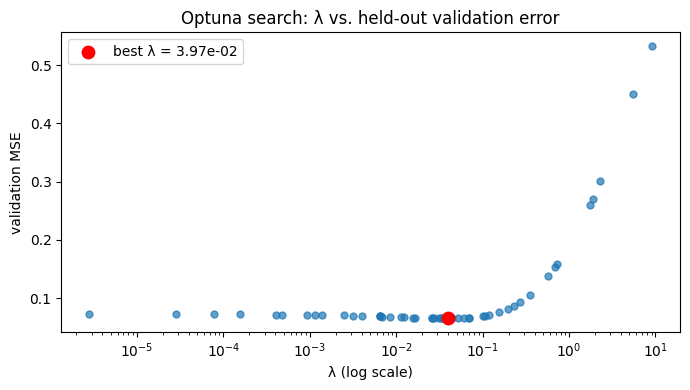

In [50]:
trials_df = study.trials_dataframe()

plt.figure(figsize=(7, 4))

# If I use the dataframe provided by optuna instead of tracking my own
# a scatter plot works best
plt.scatter(trials_df["params_lam"], trials_df["value"], s=25, alpha=0.7)
plt.scatter([lambda_star], [study.best_value], color="red", s=80,
            zorder=5, label=f"best λ = {lambda_star:.2e}")
plt.xscale("log")
plt.xlabel("λ (log scale)")
plt.ylabel("validation MSE")
plt.legend()
plt.title("Optuna search: λ vs. held-out validation error")
plt.tight_layout()
plt.show()

In [46]:
# TODO (students): select lambda on held-out error rather than accepting this value.
# Hold out the last two weeks of the training window, or use an Optuna search as the SGD page does.
#lambda_star = 1e-4

theta = sgd_fit(standardize(X_train), y_train, lambda_star)

train_resid = standardize(X_train) @ theta + y_bar - y_train
sigma_train = train_resid.std()
print(f"sigma_train = {sigma_train:.4f} standardized units "
      f"({sigma_train * y_std / y_mean * 100:.1f}% of mean load)")

sigma_train = 0.3186 standardized units (3.5% of mean load)


Report the spread of the training residuals before evaluating either new window.

Do not use the training residual spread to set the detector threshold. It is likely to be smaller than
the residual spread on unseen data. Calibrate the threshold on the control window and report the difference
in Part 4.

## Part 3: freeze and apply

Keep the fitted weights and both training scalers fixed when evaluating the other windows.

Do not refit the model on the control or event data.

Do not calculate new scaling statistics for either evaluation window. The provided function
applies the training statistics and fitted weights.


In [47]:
def apply_frozen(df, X):
    """Apply the frozen model to a window. Positive residual means the model over-predicted."""
    out = df.copy()
    y_true = z(out["load"].to_numpy())                 # training scaler
    y_pred = standardize(X) @ theta + y_bar            # training weights and feature scaler
    out["y_true"], out["y_pred"] = y_true, y_pred
    out["resid"] = y_pred - y_true
    return out


control_r = apply_frozen(control, X_control)
event_r = apply_frozen(event, X_event)

# Calibrate on unseen ordinary data, not on the training residuals.
sigma_control = control_r["resid"].std()
print(f"sigma_train   = {sigma_train:.4f}   (days the model was fitted to)")
print(f"sigma_control = {sigma_control:.4f}   (unseen ordinary days)")
print(f"ratio         = {sigma_control / sigma_train:.2f}")

# y_true and y_pred are standardized; resid is y_pred - y_true, so positive means over-prediction
event_r.head()

sigma_train   = 0.3186   (days the model was fitted to)
sigma_control = 0.5804   (unseen ordinary days)
ratio         = 1.82


,load,temp,hour,dow,y_true,y_pred,resid
t,,,,,,,
2021-02-14 00:00:00-06:00,54661.583333,26.9750,0,6,3.115874,2.622649,-0.493225
2021-02-14 01:00:00-06:00,54355.666667,26.6125,1,6,3.047034,2.261790,-0.785245
2021-02-14 02:00:00-06:00,54459.333333,26.0375,2,6,3.070362,2.320092,-0.750270
2021-02-14 03:00:00-06:00,54887.500000,25.8500,3,6,3.166711,2.418698,-0.748014
2021-02-14 04:00:00-06:00,55680.583333,25.4375,4,6,3.345177,2.876578,-0.468599


## Part 4: compare the windows

Report the mean squared error of the frozen model on the control and event windows. Express both relative to the training residual spread.

Also report the ratio of control to training residual spread. This quantifies the difference between
in-sample and out-of-sample error.

The control window immediately precedes the event and includes the beginning of the cold weather. Discuss
whether the two error distributions separate, using the values you calculate.


In [48]:
# TODO (students): per-window and per-day MSE for control and event, in units of sigma_train.

# Apply MSE formula
mse_control = np.mean(control_r["resid"] ** 2)
mse_event = np.mean(event_r["resid"] ** 2)

# Caclulate in terms of sigma_train
print(f"MSE control = {mse_control:.4f}, which is {mse_control/sigma_train**2:.2f} times sigma_train squared")
print(f"MSE event   = {mse_event:.4f}, which is {mse_event / sigma_train**2:.2f} times sigma_train squared")

# calculate per day MSEs
def per_day_mse(df):
    return df.groupby(df.index.date)["resid"].apply(lambda r: np.mean(r ** 2))

control_daily = per_day_mse(control_r)
event_daily = per_day_mse(event_r)

print("\n\nControl, per day relative to sigma_train squared:")
print((control_daily / sigma_train**2).round(2))
print("\nEvent, per day relative to sigma_train squared:")
print((event_daily / sigma_train**2).round(2))

MSE control = 0.6208, which is 6.12 times sigma_train squared
MSE event   = 25.8865, which is 255.03 times sigma_train squared


Control, per day relative to sigma_train squared:
2021-02-08    0.42
2021-02-09    5.85
2021-02-10    8.98
2021-02-11    6.34
2021-02-12    9.12
2021-02-13    5.99
Name: resid, dtype: float64

Event, per day relative to sigma_train squared:
2021-02-14     35.34
2021-02-15    729.71
2021-02-16    567.90
2021-02-17    102.68
2021-02-18     44.49
2021-02-19     50.06
Name: resid, dtype: float64


### **Discussion 1: Ratio of control to training residual spread**

In plain terms, the ratio = 1.82 represents the spread of residuals in the control window divided by the spread of the residuals in the training window. The ratio is greater than 1, which means that residuals are spread out further in control window than training window. Furthermore, the specific number 1.82 tells us that the spread in control window is almost doubly large. This makes sense because theta was fit to data it had already seen in the training window. However, the model had never seen the control window data. So, the model's ability to predict load for this out-of-sample data serves a better baseline for detecting anomalies later.

### **Discussion 2: Control vs Event MSEs**

From our results above, we know that the MSE for Control was 6.12 times the square of sigma-train, while the MSE for Event is ~42 times the MSE Control at 255.03 times the square of sigma-train.
Further, we can look at the per-day metrics to see that the lowest MSE in Event is 35.34 times sigma-train squared, whereas the highest value in control is much lower at 9.12 times sigma-train squared. This means that the control and event error distributions separate cleanly.
It is shocking to note this because we also know that the control week directly preceded the storm week, so it was already recording out of ordinary patterns. Yet, the event week data was on a different magnitude altogether that there was still a clean separation between control and event windows.

## Part 5: signed residuals

Use signed residuals to examine the direction of the model error.

Plot the signed residual over time for both windows. Then answer: during the shedding on 15 and 16
February, does the model predict too much load or too little? Explain the direction in terms of what the
model was given as input and what ERCOT was doing at the time, and say what that residual represents
physically.

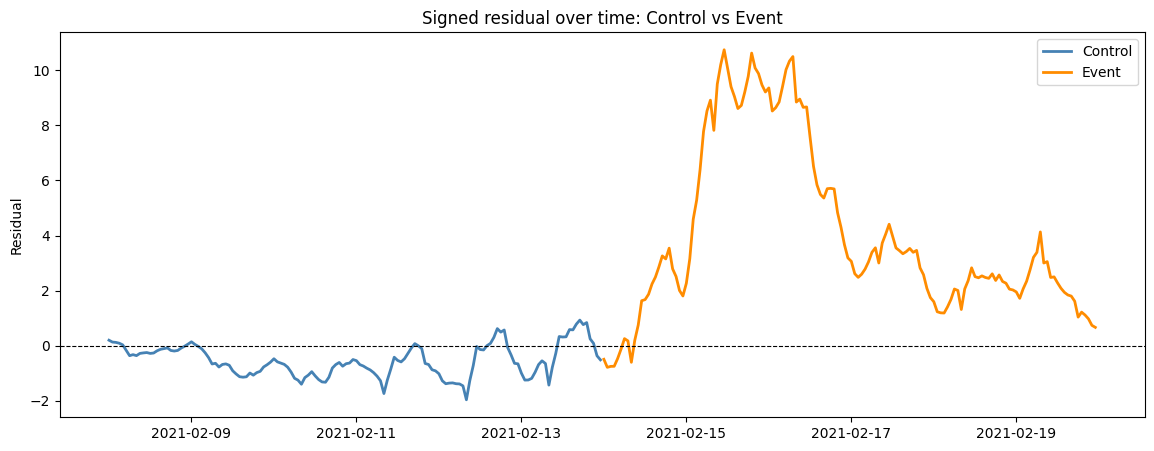

In [52]:
# TODO (students): plot the signed residual time series for the control and event windows.

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(control_r.index, control_r["resid"], color="steelblue", linewidth=2, label="Control")
ax.plot(event_r.index, event_r["resid"], color="darkorange", linewidth=2, label="Event")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_title("Signed residual over time: Control vs Event")
ax.set_ylabel("Residual")
ax.legend()
plt.show()

### **Discussion**
For most of the event week, the residuals are large and positive. For the shedding period specifically, they oscillate between +8 to +10.
The positive sign of the residual indicates that the model overpredicted. In plain terms, it predicted more load than was actually used. The model has determined this only knowing about the time of day and the temperature. It does not know that ERCOT was actively cutting power in parts of Texas to prevent a total grid collapse.
As a result of this intervention, the true y value that each y-hat was compared to was an artifically suppressed level of demand, not the true demand. The large residuals are a sum of the model error and the quantity of load cut off from the grid. It can be argued that in the physical world, the residual represents how much load was shed by ERCOT, but in truth, we don't know what proportion of the residual is owed to shedding vs error since we never physically observed the true y in which there was no intervention.
The most we can do is consider that the residual in the control week is mostly negative, which means that the model tends to underpredict. This implies that the the model's prediction for the event week would continue to be an underprediction of the true (fictional) y, telling us just how much load was shed by ERCOT. However, this is an extrapolation from control-week behavior and has no direct grounding in event-week data itself so it should be taken with a grain of salt.
Another important thing to note is that we never observed the human reaction to the extraordinary weather conditions. How humans behave in times of emergency can be very different from how they behave in normal conditions, so we don't know how erratically their reaction would've impacted the true demand for power in Texas.

## Part 6: build the detector

The detector labels an hour as unusual when the size of its residual is above a threshold:

$$\text{flag}(t) = \mathbb{1}\left[\,\lvert r(t) \rvert > k\,\sigma_{\text{control}}\,\right]$$

Here $\sigma_{\text{control}}$ is the spread of the residuals during the ordinary control week. The number
$k$ controls how sensitive the detector is. A smaller $k$ flags more hours. A larger $k$ flags fewer hours.

A **false alarm** happens when the detector flags an hour in the control week even though that week is being
treated as normal. The **false-alarm rate** is the fraction of control hours that are flagged. For example,
if 6 of 100 control hours are flagged, the false-alarm rate is 6%.

Try several values of $k$. For each value, report the percentage of control hours and event hours that are
flagged. Choose a value that keeps the control percentage reasonably low while still identifying event hours.

The same control week is used here to calculate $\sigma_{\text{control}}$ and to count false alarms, so the
result applies only to this sample. A larger study would use separate ordinary weeks to choose and evaluate
the threshold.

Finally, consider duration. One unusual hour may be noise, while several unusual hours in a row provide
stronger evidence of an event. Briefly describe how consecutive flags could improve the detector.

In [53]:
# TODO (students): try several values of k, report the flagged percentages for both windows, and choose k.

k_values = [1, 1.5, 2, 2.25, 2.5, 2.75, 3, 3.5, 4, 4.5, 5]

print(f"{'k':>5} {'control flagged %':>20} {'event flagged %':>18}     {"delta"}")
for k in k_values:
    threshold = k * sigma_control
    control_flag_rate = (control_r["resid"].abs() > threshold).mean() * 100
    event_flag_rate = (event_r["resid"].abs() > threshold).mean() * 100
    delta = event_flag_rate - control_flag_rate
    print(f"{k:>5} {control_flag_rate:>19.1f}% {event_flag_rate:>17.1f}%     {delta:.2f}")

    k    control flagged %    event flagged %     delta
    1                57.6%              95.8%     38.19
  1.5                31.9%              91.0%     59.03
    2                15.3%              88.9%     73.61
 2.25                 8.3%              86.1%     77.78
  2.5                 2.1%              84.7%     82.64
 2.75                 1.4%              84.7%     83.33
    3                 0.7%              80.6%     79.86
  3.5                 0.0%              73.6%     73.61
    4                 0.0%              66.7%     66.67
  4.5                 0.0%              54.2%     54.17
    5                 0.0%              49.3%     49.31


### **Discussion**
The best k value I see is 2.75 since it maximizes the difference between event flagged and control flagged. It flags 84.7% of event hours with only 1.4% false-alarm rate (proportion of control hours flagged). I initially computed results values of k with 0.5 difference, and when it became clear that the ideal k landed somewhere between 2 and 3, I drilled down into 0.25 intervals. This was useful because going from 2.5 to 2.75 gives us false alarm (2.1% to 1.4%) without incurring any additional cost in terms of event flagged %.

It would definitely be useful to flag consecutive unusual hours as an event since it represents sustained conditions. It would help the detector identify the severity of the event since extenuating conditions for a long time are more dangerous than a one-off blip. This approach would assign less significance to a single unusual hour and lower the false alarm rate, allowing the detector to focus on true events.

## Part 7: write up

Answer the questions in the Markdown cells below. Replace each placeholder with your answer. Refer to the
numbers, plots, and tables you produced above. Do not write a separate README.

### 1. How accurate is the baseline?

Report sigma_train, sigma_control, and their ratio. What does the difference tell you?

**Answer:** Results from Part 3 tell us - sigma_train = 0.3186, sigma_control = 0.5804, and ratio = 1.82

Each sigma represents the spread of the residuals from the training and control windows. The difference in these numbers tells us the spread of control residuals tends to be 82% greater than the spread of the training residuals. Theta was trained to fit the in-sample data, not the out-of-sample data, so sigma-training would've been an optimistic baseline for model error while sigma-control tells us how well the model performs on data it has never seen before. The disparity between the two justifies using the out-of-sample metric as a true baseline for model error.


### 2. Does the storm week look different?

Compare the control and event errors. State whether the residuals separate the two weeks and cite your results.

**Answer:** Part 4 tells us that the MSE_control ≈ 6.12 times sigma_train² while MSE_event ≈ 255.03 times sigma_train², which is roughly 42 times larger for the event week.

Furthermore, the per-day metrics tell us that the lowest MSE_Event is 35.34 times sigma_train², whereas the highest value in control is much lower at 9.12 times sigma_train². In my opinion, this classifies as a clean seperation between the control and event error distributions.

### 3. What happened during load shedding?

On 15 and 16 February, were the residuals mostly positive or negative? Explain what that sign means in terms
of predicted and observed load.

**Answer:** During the shedding period, the residuals were mostly positive, which means the model overpredicted. This means that the predicted load was greater than the observed load.

The model does not account for the fact that observed load was a reflection of the artificial ceiling set by ERCOT in that period, not the true load demanded by people.

### 4. How did your detector perform?

State the value of k you chose. Report the percentage of control hours and event hours that it flagged. The
control percentage is the false-alarm rate for this exercise.

**Answer:** I chose k = 2.75

I randomly picked k values in 0.5 invervals between 1 and 5 to test. Since the goal was the maximize events flagged % while minimizing control flagged %, I calculated delta = events flagged - control flagged and saw this delta was highest around 2.5

I drilled deeper and added 2.25 and 2.75 was well to see if they performed better, which proved to be useful because 2.75 gave me a better false-alarm rate at the same percentage for events flagged. I believe that my detector performed well because a false-alarm rate of 1.4% is sufficiently low and a events flagged rate of 84.7% is sufficiently high for our model.

### 5. What else could cause a large residual?

Give one normal situation that this model might flag and explain how you could distinguish it from a grid
event.

**Answer:** This model could produce a large residual and flag a single unusually cold hour, like a brief overnight cold snap, even if conditions don't persist long enough to constitute a real storm. The detector would note that the true load during that unusually cold hour was way off what the model predicted and raise alarm. However, if the detector required several hours of erronous predictions to raise alarms, a one-off anomaly could be distinguished from a true grid event.

### 6. How could duration improve the detector?

Explain how you would use several flagged hours in a row instead of treating every hour separately.

**Answer:**
In the simplest way, we can require n number of flagged hours to occur one after the other to raise alarm.

In a more detailed way, once we see a residual greater than the hourly threshhold, we can begin calculating a running score that assigns more value to large residuals the longer they go on. For example, if x(i) is the residual at hour i, score = sum( i * x(i) ) = 1x(1) + 2x(2) + 3x(3) + ...

Alternately we can use a polynomial approach that would increase the score more dramatically the longer the residuals remained erratic: score = sum ( x(i)^i ) = x(1)^1 + x(2)^2 + x(3)^3 + ...

We can create a different threshhold for this score and only raise alarms when the score goes above the threshhold.

We would still need to figure out when when the score resets to 0. Perhaps, it could require n number of consecutive readings below the hourly threshhold.

## Submitting

Follow the [assignment submission guide](https://aegean.ai/aiml-common/resources/environment/assignment-submission). Commit
this notebook with all cell outputs saved, and submit the complete GitHub URL of its directory.